# Figure 3 — Steady-State Cell Interaction & Spatial Organization

## Load libraries

In [1]:
library(Seurat)
library(ggplot2)
library(ggpubr)
library(dplyr)
library(stringr)
library(grid)
library(tibble)
library(parallel)
library(RColorBrewer)
library(patchwork)
library(future)
library(ComplexHeatmap)
library(clusterProfiler)
library(viridis)
library(tidyr)
library(ggrepel)
library(Signac)
library(CellChat)
library(reshape2)
library(gridExtra)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




clusterProfiler v4.6.0  For help: https://yulab-smu.top/biomedical-knowledg

## Setup: directories, colors, theme

In [2]:
DATA_DIR <- "data"
OUT_DIR  <- "output"
dir.create(OUT_DIR, showWarnings = FALSE)

# ---- Color & Theme ----
colorlist <- c("#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941",
               "#006FA6", "#A30059", "#FFE4E1", "#0000A6", "#63FFAC",
               "#B79762", "#004D43", "#8FB0FF", "#997D87", "#5A0007",
               "#809693", "#1B4400", "#4FC601", "#3B5DFF", "#FF2F80",
               "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9",
               "#B903AA", "#DDEFFF", "#7B4F4B", "#A1C299", "#0AA6D8",
               "#00A087FF", "#4DBBD5FF", "#E64B35FF", "#3C5488FF", "#F38400",
               "#A1CAF1", "#C2B280", "#848482", "#E68FAC", "#0067A5",
               "#F99379", "#604E97", "#F6A600", "#B3446C", "#DCD300",
               "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26",
               "#191970", "#000080", "#6495ED", "#1E90FF", "#00BFFF",
               "#00FFFF", "#FF1493", "#FF00FF", "#A020F0", "#63B8FF",
               "#008B8B", "#54FF9F", "#00FF00", "#76EE00", "#FFF68F")

black_theme <- function() {
  theme(
    panel.grid = element_blank(),
    panel.background = element_rect(fill = NA),
    panel.border = element_rect(color = "white", linewidth = 0.5, fill = NA),
    plot.title = element_text(hjust = 0.5, size = 14, color = "white"),
    plot.background = element_rect(fill = 'black'),
    axis.line = element_line(color = "white", linewidth = 0),
    axis.text = element_text(color = "white", size = 12),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0.5),
    axis.title = element_text(color = "white", size = 14),
    axis.ticks = element_line(color = "white", linewidth = 0.5),
    legend.title = element_text(color = "white", size = 12),
    legend.text = element_text(color = "white", size = 12),
    legend.key = element_rect(fill = NA),
    legend.background = element_rect(fill = NA),
    legend.position = "right"
  )
}

## Load Seurat object & metadata

In [3]:
# ---- Load Seurat object ----
obj <- readRDS(file.path(DATA_DIR, "HF_RNA_postQC_rpca_241011.rds"))
meta <- readRDS(file.path(DATA_DIR, "HF_RNA_rpca_meta_240612.rds"))
Idents(obj) <- 'RNA'
meta$Age <- as.numeric(as.character(meta$Age))
meta$AgeGroup <- sapply(meta$Age, function(a) {
  if (is.na(a)) NA
  else if (3 <= a & a <= 17) "Juvenile"
  else if (18 <= a & a <= 39) "Prime age"
  else if (40 <= a & a <= 59) "Mid age"
  else "Old age"
})
meta$AgeGroup <- factor(meta$AgeGroup, levels = c("Juvenile", "Prime age", "Mid age", "Old age"), ordered = FALSE)
meta$sample <- ifelse(grepl("^H[BO]", meta$sample), "HO",
                     ifelse(meta$sample == "AB" | meta$sample == "AO", "AO", meta$sample))
meta$sample <- factor(meta$sample, levels = c('HO', 'AO', 'AF'))
obj@meta.data <- meta[colnames(obj),]

RCTD.color <- read.csv(file.path(DATA_DIR, "RCTD.color1_251210.csv"))
color1 <- RCTD.color$Color
names(color1) <- RCTD.color$abbreviation

RCTD.color2 <- read.delim(file.path(DATA_DIR, "RCTD.color_LastlEdition240612.txt"), header = TRUE, sep = "\t")
recoding <- setNames(RCTD.color2$abbreviation, RCTD.color2$order)

## Figure 3a — Steady-State Cell Interaction (Source Barplot)

水平并列柱状图：展示 Young 组各细胞类型作为 source 的通讯概率总和。

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.
Adding missing grouping variables: `type`


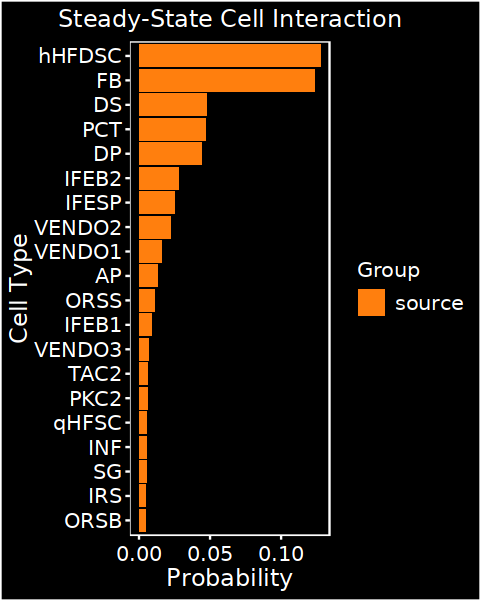

In [4]:
nep_3a <- read.csv(file.path(DATA_DIR, "Figure3a_cellchat_nep.csv"))
nep_3a <- subset(nep_3a, age_group == "Young")

data.nep <- nep_3a %>%
  select(source, target, prob) %>%
  gather(key = "type", value = "celltype", source, target)
data.nep <- data.nep %>%
  group_by(type, celltype) %>%
  summarise(avg_prob = sum(prob))

data.nep$celltype[data.nep$celltype == "Unknown"] <- "Schwann"
data.nep$celltype <- recode(data.nep$celltype, !!!recoding)

data.count <- data.nep %>%
  select(celltype, avg_prob) %>%
  group_by(celltype) %>%
  arrange(avg_prob)
data.nep <- subset(data.nep, celltype %in% tail(unique(data.count$celltype), 20))

source_3a <- subset(data.nep, grepl("source", type))
source_3a <- source_3a %>% arrange(desc(avg_prob))
source_3a <- source_3a[!is.na(source_3a$type), ]

celltype_order <- source_3a %>% arrange(avg_prob) %>% pull(celltype) %>% unique()
source_3a$celltype <- factor(source_3a$celltype, levels = celltype_order)

p_3a <- ggplot(source_3a, aes(x = celltype, y = avg_prob, fill = type)) +
  geom_bar(stat = "identity", position = position_dodge(0.7)) +
  scale_fill_manual(values = c("source" = "#FF7F0E")) +
  labs(title = "Steady-State Cell Interaction", x = "Cell Type", y = "Probability", fill = "Group") +
  black_theme() + coord_flip()

ggsave(p_3a, file = file.path(OUT_DIR, "Figure3a_steady_state_cell_interaction_source.pdf"), width = 4, height = 5)
options(repr.plot.width =4, repr.plot.height = 5)
p_3a

## Figure 3b — Spatial Plot

空间图由 Python notebook `Figure3b_spatial.ipynb` 生成。

## Figure 3c — DotPlot Young hHFDSC/DP Markers

DotPlot 展示 Young 样本中 hHFDSC / DP 的 marker 基因表达。

Warning message:
“Could not find WNT2 in the default search locations, found in RNA assay instead”
Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


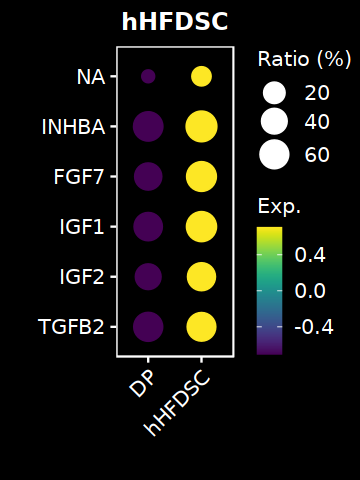

In [5]:
Idents(obj) <- "batch1"
batch_values <- c("5-HB-3y", "12-HB-55y", "16-HB-67y", "17-HB-66y")
HB <- subset(obj, idents = batch_values, invert = TRUE)
HB$Age <- as.numeric(as.character(HB$Age))
young_3c <- subset(HB, subset = Age < 30 & sample_type == 'HB' & Abbreviation %in% c('DP', 'hHFDSC'))

gene_3c <- rev(c("WNT2", "INHBA", "FGF7", "IGF1", "IGF2", "TGFB2"))  # TODO: fill gene list
p_3c <- DotPlot(young_3c, features = gene_3c, group.by = 'Abbreviation') +
  coord_flip() +
  scale_color_viridis(option = "viridis") +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(3, 8)) +
  guides(size = guide_legend(title = "Ratio (%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  black_theme() + labs(x = "", y = "", title = "hHFDSC") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_3c, file = file.path(OUT_DIR, "Figure3c_young_DP_hHFDSC_DotPlot.pdf"), width = 3, height = 4)
options(repr.plot.width =3, repr.plot.height = 4)
p_3c

## Figure 3h — hHFDSC/DP GO Heatmap

geom_tile 热图：展示 hHFDSC 和 DP 的 GO 富集结果。

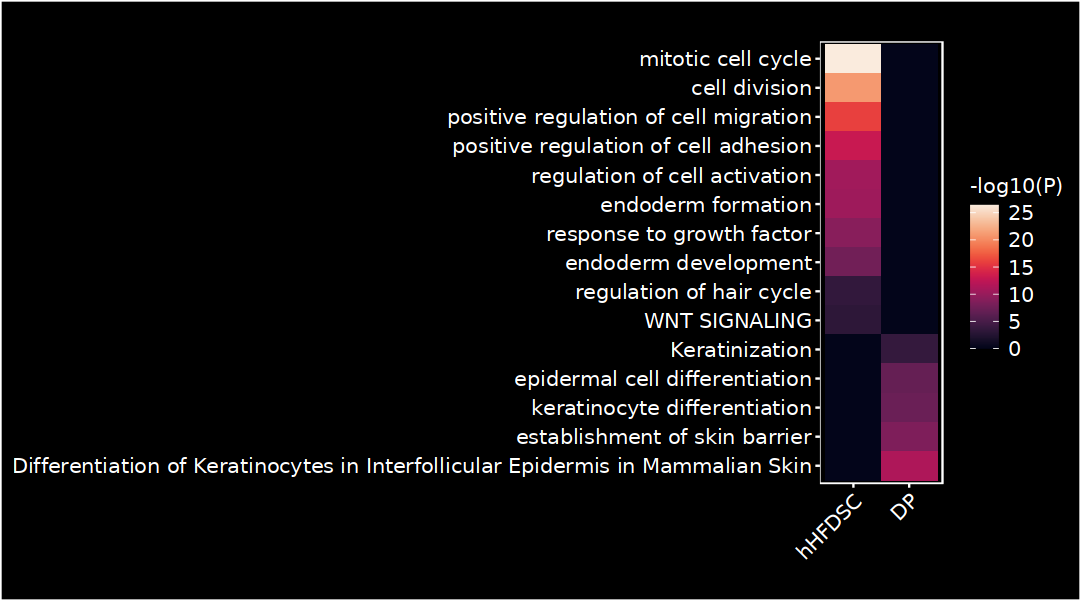

In [6]:
df_3h <- data.frame(
  Description = c(
    "mitotic cell cycle", "cell division", "positive regulation of cell migration",
    "positive regulation of cell adhesion", "regulation of cell activation",
    "endoderm formation", "response to growth factor", "endoderm development",
    "regulation of hair cycle", "WNT SIGNALING",
    "Differentiation of Keratinocytes in Interfollicular Epidermis in Mammalian Skin",
    "establishment of skin barrier", "keratinocyte differentiation",
    "epidermal cell differentiation", "Keratinization"
  ),
  hHFDSC = c(-26.41, -20.92, -15.96, -13.01, -10.55,
             -10.37, -9.08, -7.67, -3.48, -3.13,
             0, 0, 0, 0, 0),
  DP = c(0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         -11.33, -8.46, -7.21, -6.89, -3.64)
)

df_3h$hHFDSC <- -df_3h$hHFDSC
df_3h$DP <- -df_3h$DP
df_3h <- df_3h[order(-df_3h$hHFDSC, df_3h$DP), ]
df_3h$Description <- factor(df_3h$Description, levels = rev(df_3h$Description))

df_melt_3h <- melt(df_3h, id.vars = "Description", variable.name = "Cell_Type", value.name = "-log10(P)")

p_3h <- ggplot(df_melt_3h, aes(x = Cell_Type, y = Description, fill = `-log10(P)`)) +
  geom_tile(color = NA) +
  scale_fill_viridis(option = "rocket", direction = 1) +
  labs(x = "", y = "", title = "") +
  black_theme()+theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_3h, file = file.path(OUT_DIR, "Figure3h_hHFDSC_DP_GO_heatmap.pdf"), width = 9, height = 5)
options(repr.plot.width =9, repr.plot.height = 5)
p_3h

## Figure 3l — Experiment UMAP (Cell type + Group)

DimPlot/UMAP：展示实验数据中细胞类型和分组的分布，附图例色块。

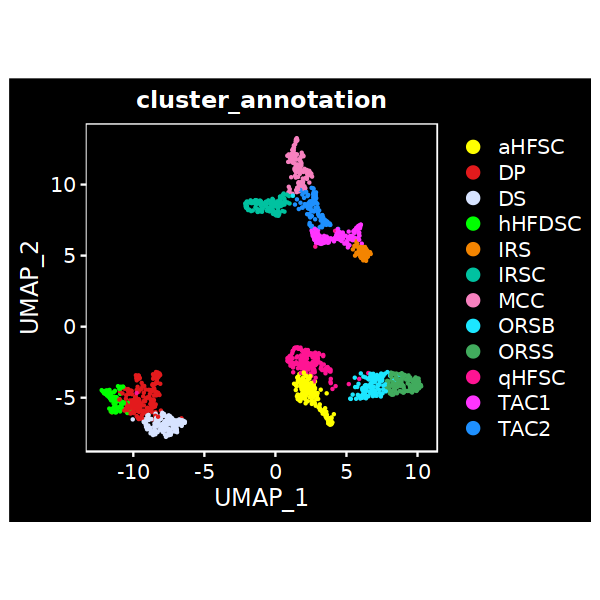

In [7]:
sub_com <- readRDS(file.path(DATA_DIR, "Figure3l_experiment.rds"))

p_3l_celltype <- DimPlot(sub_com, reduction = "umap", cols = color1, group.by = "cluster_annotation",
                          raster = FALSE, pt.size = 0.2) + black_theme()+ coord_fixed()
ggsave(p_3l_celltype, file = file.path(OUT_DIR, "Figure3l_celltype_UMAP.png"), width = 5, height = 5)
options(repr.plot.width =5, repr.plot.height = 5)
p_3l_celltype

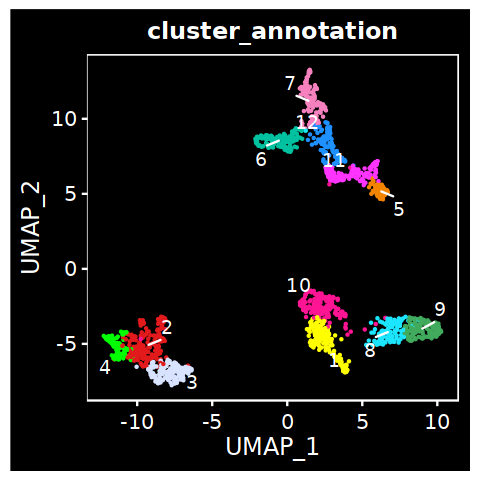

In [8]:
# 对cluster加数字
cluster_levels <- sort(unique(sub_com$cluster_annotation))
cluster_map <- setNames(seq_along(cluster_levels), cluster_levels)
sub_com$cluster_num <- factor(cluster_map[sub_com$cluster_annotation], levels = seq_along(cluster_levels))

# 计算每个cluster中位数UMAP坐标用于标注
cluster_centers <- as.data.frame(Embeddings(sub_com, "umap")) |>
  rownames_to_column("cell") |>
  left_join(sub_com@meta.data |> rownames_to_column("cell"), by = "cell") |>
  group_by(cluster_num) |>
  summarise(UMAP_1 = median(UMAP_1), UMAP_2 = median(UMAP_2))

# UMAP绘图+簇数字标注
p_3l_celltype_num <- DimPlot(sub_com, reduction = "umap", cols = color1, group.by = "cluster_annotation", raster=F, pt.size=0.2) +
  black_theme() + coord_fixed()+
  geom_label_repel(data=cluster_centers, aes(x=UMAP_1, y=UMAP_2, label=cluster_num),
                   color="white", fill=NA, size=4, label.r=0.1, label.size=NA,
                   segment.color="white", segment.size=0.5, show.legend=F) +
  guides(color=guide_legend(override.aes=list(shape=15, size=4), title='Cell types', ncol=1)) +
  NoLegend()
options(repr.plot.width =4, repr.plot.height = 4)

p_3l_celltype_num
ggsave(p_3l_celltype_num, file = file.path(OUT_DIR, "Figure3l_celltype_UMAP_num.pdf"), width = 5, height = 5)

In [9]:
head(sub_com,2)

,orig.ident,nCount_RNA,nFeature_RNA,batch,tissue,percent.mt,percent.ribo,percent_mito,percent_ribo,percent_mito_ribo,⋯,S.Score,G2M.Score,Phase,species,group,predicted.id,integrated_snn_res.0.5,integrated_snn_res.1.5,cluster_annotation,cluster_num
,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>,<fct>
CELL220_N4_1_1_1_1_1,BGI_study,6340,2571,1-HB-77y-1b,scalp,1.024429,16.07565,1.024429,16.07565,17.10008,⋯,-0.005582316,-0.08163018,G1,Nor_human,NOR,NA,1,0,DP,2
CELL789_N2_1_1_1_1_1,BGI_study,6893,2448,1-HB-77y-1b,scalp,1.449275,12.95652,1.449275,12.95652,14.40580,⋯,-0.021793512,-0.10680612,G1,Nor_human,NOR,NA,1,0,DP,2


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


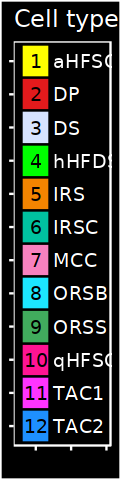

In [10]:
legend_3l <- unique(sub_com@meta.data[, c('cluster_annotation', 'cluster_num')])
legend_3l <- rev(legend_3l)

color_text <- "unknown'#363636'EGD'#C2B280'hHFDSC'#00FF00'PKC2'#1c6eb0'skMELA'#63FFAC'IRSC'#00C2A0'TAC1'#FF34FF'ERY'#999999'VENDO1'#9101ab'PCT'#0000A6'AP'#b43d44'IFESP'#FE4945'aHFSC'#FFFF00'TAC2'#1E90FF'VENDO2'#7B4F4B'FB'#A30059'IRS'#F38400'DS'#D7E3FF'PKC1'#FFFF99'MCC'#F781BF'IST'#4FC601'IFEB1'#A020F0'TC'#3B5DFF'MACRO'#8b9e32'ORSS'#41AB5D'ORSB'#1CE6FF'qHFSC'#FF1493'DP'#E31A1C'IFESU'#c9c100'LGS'#b236a4'SG'#df00f7'IFEB2'#4abcf7'INF'#f7ab4a'IFEG'#f74a9d'VENDO3'#96f700'MAST'#00f76b'EG'#5036b2'LENDO'#00c91c'dqHFSC'#002df7'SW'#5500f7'ILC'#6ff74a'hfMELA'#b26c1b'"
color_parts <- strsplit(color_text, "'")[[1]]
color_parts <- color_parts[color_parts != ""]
color_df <- data.frame(
  cluster_annotation = color_parts[seq(1, length(color_parts), 2)],
  color = color_parts[seq(2, length(color_parts), 2)]
)
plot_data_3l <- legend_3l %>% left_join(color_df, by = "cluster_annotation")

p_3l_legend <- ggplot(plot_data_3l) +
  geom_tile(aes(x = 1, y = cluster_annotation, fill = cluster_annotation),
            color = "black", size = 0.5, width = 0.8) +
  geom_text(aes(x = 1, y = cluster_annotation, label = cluster_num), color = "black", size = 4) +
  geom_text(aes(x = 1.5, y = cluster_annotation, label = cluster_annotation), color = "white", hjust = 0, size = 4) +
  scale_fill_manual(values = setNames(plot_data_3l$color, plot_data_3l$cluster_annotation)) +
  scale_y_discrete(limits = rev) +
  ggtitle("Cell types") +
  black_theme() +
  theme(plot.title = element_text(hjust = 0, color = "white", size = 14),
        legend.position = "none", axis.title = element_blank(),
        axis.text = element_blank(), panel.grid = element_blank()) +
  xlim(0.5, 3)

ggsave(p_3l_legend, file = file.path(OUT_DIR, "Figure3l_celltype_legend.pdf"), width = 1, height = 4)
options(repr.plot.width =1, repr.plot.height = 4)
p_3l_legend

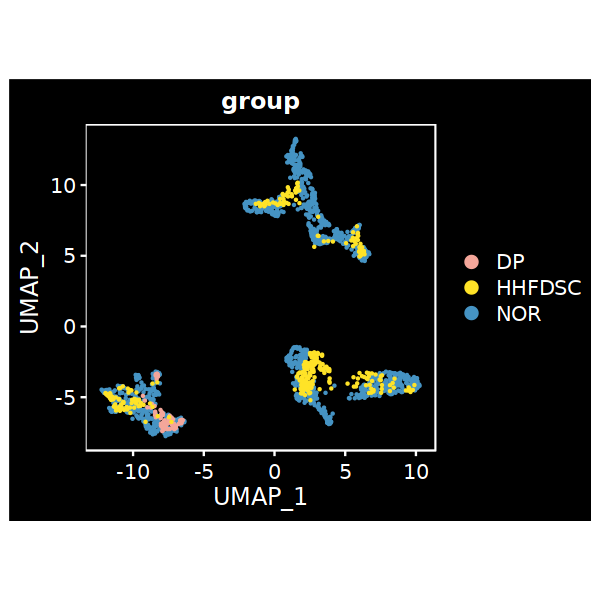

In [11]:
colors_group <- c("#f4a69a", "#ffe327", "#4593c3")
p_3l_group <- DimPlot(sub_com, reduction = "umap", cols = colors_group, group.by = "group",
                       raster = FALSE, pt.size = 0.2) +
  black_theme() + coord_fixed()

ggsave(p_3l_group, file = file.path(OUT_DIR, "Figure3l_group_UMAP.pdf"), width = 5, height = 5)
options(repr.plot.width =5, repr.plot.height = 5)
p_3l_group

## Figure 3m — Cell Proportion Barplot

堆叠比例柱状图：展示各实验组中细胞类型的比例变化。

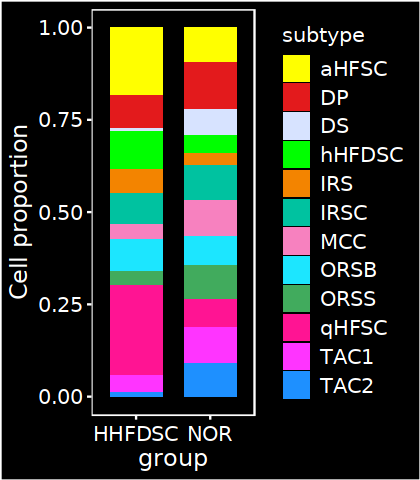

In [12]:
Idents(sub_com) <- "cluster_annotation"
Cellratio_3m <- prop.table(table(Idents(sub_com), sub_com$group), margin = 2)
Cellratio_3m <- as.data.frame(Cellratio_3m)
colnames(Cellratio_3m) <- c("subtype", "age_group", "Freq")

Cellratio_3m <- subset(Cellratio_3m, !age_group == 'DP')
Cellratio_3m$subtype <- as.character(Cellratio_3m$subtype)
Cellratio_3m$subtype <- factor(Cellratio_3m$subtype, levels = sort(unique(Cellratio_3m$subtype)))

p_3m <- ggplot(Cellratio_3m) +
  geom_bar(aes(x = age_group, y = Freq, fill = subtype), stat = "identity", width = 0.7, colour = NA) +
  black_theme() +
  labs(x = 'group', y = 'Cell proportion') +
  scale_fill_manual(values = color1)

ggsave(p_3m, file = file.path(OUT_DIR, "Figure3m_cell_proportion_barplot.pdf"), width = 3.5, height = 4)
options(repr.plot.width =3.5, repr.plot.height = 4)
p_3m